# Welcome to Viewport
## A world dedicated for quick experiment and data visualization

In [1]:
from chunker import Chunker
from collector import Collector
from rag import Augmentor, Retriever, Judger

Visualization on ChromaDB

In [46]:
import chromadb

chroma_client = chromadb.PersistentClient(path="./chroma_db")
collection = chroma_client.get_collection("policy_procedures")

data = collection.get(
    include=["embeddings", "metadatas", "documents"]
)

n = collection.count()
print("Number of vectors (items) in collection:", n)

Number of vectors (items) in collection: 38


In [48]:
n = collection.count()
data = collection.get(include=["embeddings","metadatas","documents"], limit=5000, offset=0)

print(len(data["ids"]))

38


In [45]:
embeddings = data["embeddings"]
documents = data["documents"]
metadatas = data["metadatas"]
ids = data["ids"]
len(ids)


38

Scatter plot of the embeddings

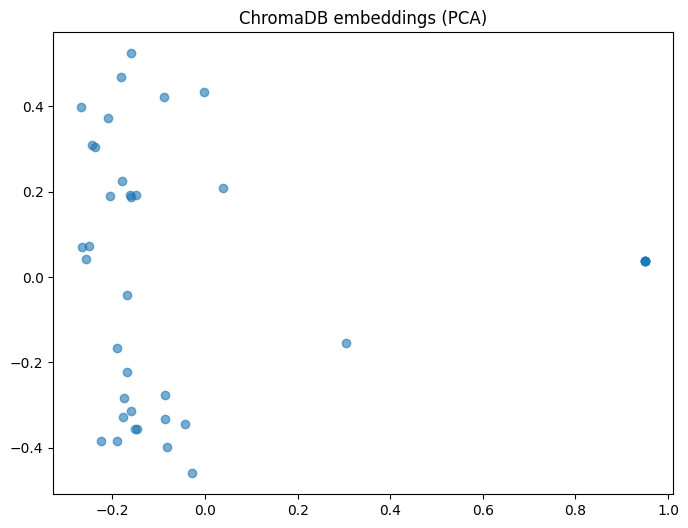

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = np.array(embeddings)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], alpha=0.6)
plt.title("ChromaDB embeddings (PCA)")
plt.show()


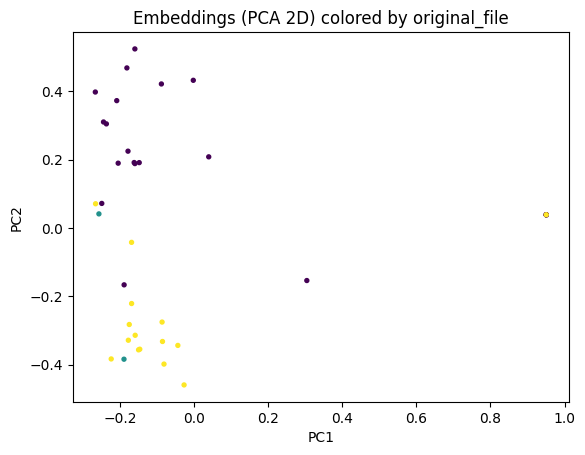

In [39]:

key = "original_file"  
labels = [m.get(key, "NA") if m else "NA" for m in metadatas]

# mappa label -> int
uniq = {v:i for i,v in enumerate(sorted(set(labels)))}
c = np.array([uniq[v] for v in labels])

plt.figure()
sc = plt.scatter(X_2d[:,0], X_2d[:,1], s=8, c=c)
plt.title(f"Embeddings (PCA 2D) colored by {key}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()



In [38]:
inv = {i:lab for lab,i in uniq.items()}  # int -> label

mapping = []
for i in range(len(inv)):
    rgba = sc.cmap(sc.norm(i))  # colore reale associato all'indice i
    mapping.append({"original_file": inv[i], "color_index": i, "rgba": rgba})

map_df = pd.DataFrame(mapping).sort_values("original_file")
display(map_df)

,original_file,color_index,rgba
0,Access_Management_Procedure.txt,0,"(0.267004, 0.004874, 0.329415, 1.0)"
1,Backup_and_Disaster_Recovery_Procedure.txt,1,"(0.127568, 0.566949, 0.550556, 1.0)"
2,Incident_Management_Procedure.txt,2,"(0.993248, 0.906157, 0.143936, 1.0)"


In [ ]:
unique_labels = sorted(set(labels))
print("Unique labels:", len(unique_labels))
for lab in unique_labels:
    print(lab)


['Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Access_Management_Procedure.txt',
 'Backup_and_Disaster_Recovery_Procedure.txt',
 'Backup_and_Disaster_Recovery_Procedure.txt',
 'Incident_Management_Procedure.txt',
 'Incident_Management_Procedure.txt',
 'Incident_Management_Procedure.txt',
 'Incident_Management_Procedure.txt'